Dataset loaded successfully
Dataset shape: (740, 7)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
Index: 740 entries, 0 to 753
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   State                 740 non-null    object        
 1   Date                  740 non-null    datetime64[ns]
 2   Frequency             740 non-null    object        
 3   Unemployment_Rate     740 non-null    float64       
 4   Employed              740 non-null    float64       
 5   Labour_Participation  740 non-null    float64       
 6   Area                  740 non-null    object        
dtypes: datetime64[ns](1), float64(3), object(3)
memory usage: 46.2+ KB
None

Statistical Summary:
                                Date  Unemployment_Rate      Employed  \
count                            740         740.000000  7.400000e+02   
mean   2019-12-12 18:36:58.378378496          11.787946  7.2

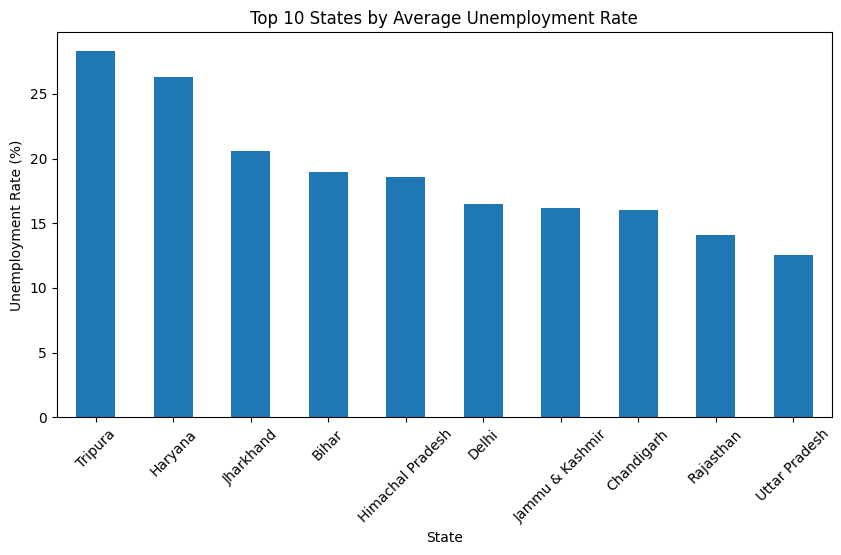

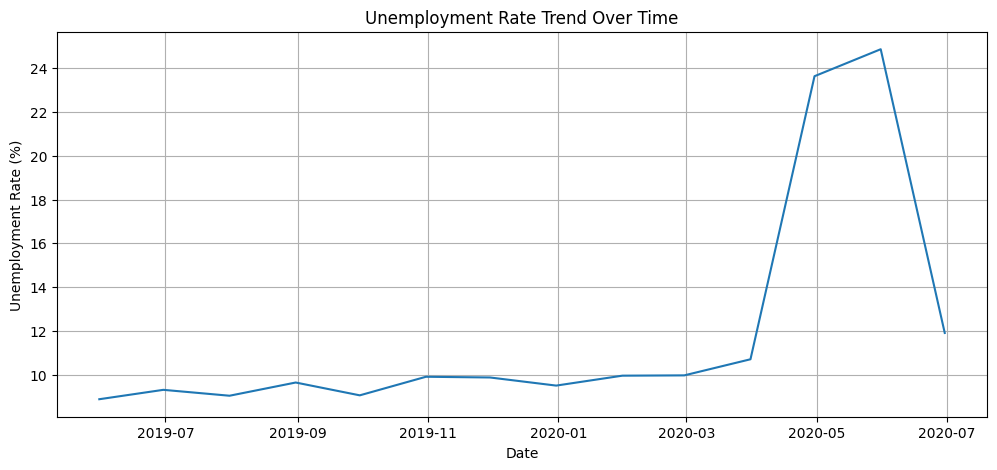


Average Unemployment Rate Before Covid-19: 9.51
Average Unemployment Rate During Covid-19: 17.77


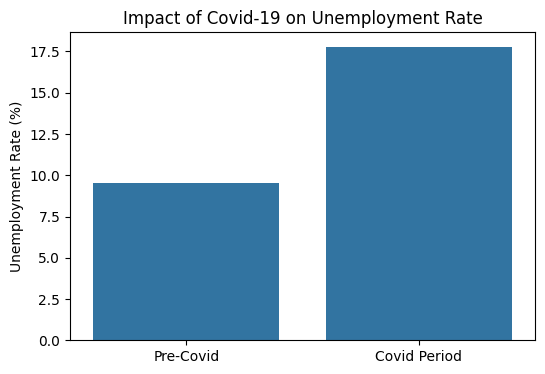

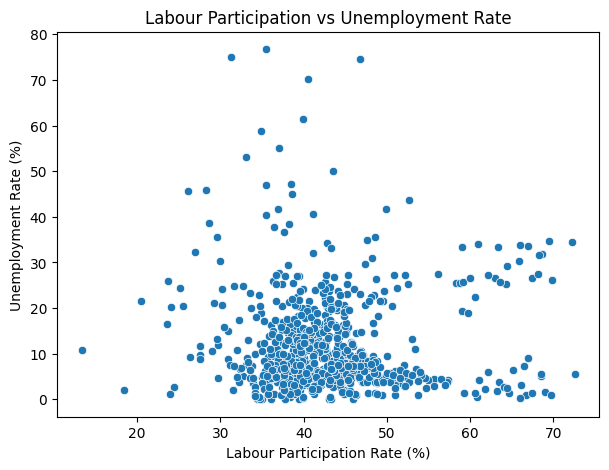

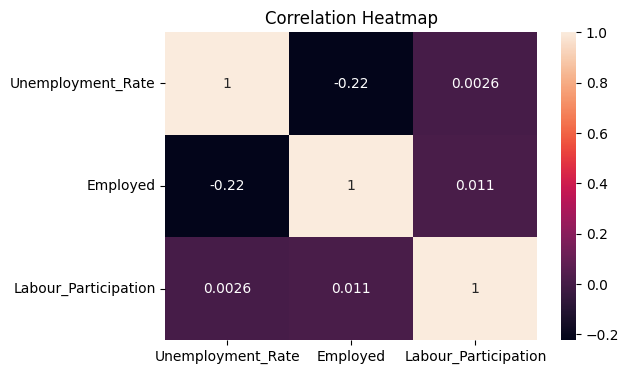


========== KEY INSIGHTS ==========
1. Unemployment rate increased significantly during the Covid-19 period.
2. There are clear differences in unemployment levels across states.
3. The unemployment trend shows fluctuations over time.
4. Labour participation rate has a noticeable relationship with unemployment.
5. These insights can help in forming employment and economic policies.


In [1]:
# ==========================================
# Unemployment Analysis with Python
# ==========================================

# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Ignore warnings
warnings.filterwarnings("ignore")

# ==========================================
# Load the dataset
# ==========================================
df = pd.read_csv("Unemployment in India.csv")

# Clean column names
df.columns = df.columns.str.strip()

# Rename columns for easier use
df.rename(columns={
    'Region': 'State',
    'Estimated Unemployment Rate (%)': 'Unemployment_Rate',
    'Estimated Employed': 'Employed',
    'Estimated Labour Participation Rate (%)': 'Labour_Participation'
}, inplace=True)

# Convert 'Date' column to datetime format
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')

# Remove missing values
df.dropna(inplace=True)

print("Dataset loaded successfully")
print("Dataset shape:", df.shape)

# ==========================================
# Basic Data Exploration
# ==========================================
print("\nDataset Information:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

# ==========================================
# State-wise Unemployment Analysis
# ==========================================
state_unemployment = df.groupby('State')['Unemployment_Rate'].mean().sort_values(ascending=False)

print("\nTop 5 States with Highest Unemployment Rate:")
print(state_unemployment.head())

# Bar plot for top 10 states
plt.figure(figsize=(10,5))
state_unemployment.head(10).plot(kind='bar')
plt.title("Top 10 States by Average Unemployment Rate")
plt.xlabel("State")
plt.ylabel("Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.show()

# ==========================================
# Monthly Trend Analysis
# ==========================================
monthly_trend = df.groupby('Date')['Unemployment_Rate'].mean()

plt.figure(figsize=(12,5))
plt.plot(monthly_trend.index, monthly_trend.values)
plt.title("Unemployment Rate Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.grid(True)
plt.show()

# ==========================================
# Covid-19 Impact Analysis
# ==========================================
pre_covid = df[df['Date'] < '2020-03-01']
covid_period = df[df['Date'] >= '2020-03-01']

pre_covid_avg = pre_covid['Unemployment_Rate'].mean()
covid_avg = covid_period['Unemployment_Rate'].mean()

print("\nAverage Unemployment Rate Before Covid-19:", round(pre_covid_avg, 2))
print("Average Unemployment Rate During Covid-19:", round(covid_avg, 2))

# Visualization of Covid impact
plt.figure(figsize=(6,4))
sns.barplot(x=['Pre-Covid','Covid Period'], y=[pre_covid_avg, covid_avg])
plt.title("Impact of Covid-19 on Unemployment Rate")
plt.ylabel("Unemployment Rate (%)")
plt.show()

# ==========================================
# Labour Participation vs Unemployment
# ==========================================
plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x='Labour_Participation', y='Unemployment_Rate')
plt.title("Labour Participation vs Unemployment Rate")
plt.xlabel("Labour Participation Rate (%)")
plt.ylabel("Unemployment Rate (%)")
plt.show()

# ==========================================
# Correlation Analysis
# ==========================================
plt.figure(figsize=(6,4))
sns.heatmap(df[['Unemployment_Rate','Employed','Labour_Participation']].corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

# ==========================================
# Final Insights
# ==========================================
print("\n========== KEY INSIGHTS ==========")
print("1. Unemployment rate increased significantly during the Covid-19 period.")
print("2. There are clear differences in unemployment levels across states.")
print("3. The unemployment trend shows fluctuations over time.")
print("4. Labour participation rate has a noticeable relationship with unemployment.")
print("5. These insights can help in forming employment and economic policies.")